# Trabalho Prático 1 - INF01017
## Análise Exploratória de Dados (EDA)
### Dataset: Ames Mutagenicity

**Objetivo:** Realizar análise exploratória completa do dataset para compreender suas características, distribuições e padrões.

---

## 1. Imports e Configurações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Seed para reprodutibilidade
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
import os

# Criar diretório para salvar figuras
os.makedirs('../results/figures/eda/', exist_ok=True)
print('✓ Diretório de figuras criado!')

✓ Diretório de figuras criado!


## 2. Carregamento dos Dados

In [2]:
# Carregar dataset
df = pd.read_csv('../data/raw/ames_mutagenicity_data.csv')

print(f"Shape do dataset: {df.shape}")
print(f"Número de amostras: {df.shape[0]:,}")
print(f"Número de features: {df.shape[1]}")

Shape do dataset: (5536, 1371)
Número de amostras: 5,536
Número de features: 1371


In [3]:
# Primeiras linhas
df.head()

,Id,Name,CAS,SMILES RDKit,ABC,ABCGG,nAcid,nBase,SpAbs_A,SpMax_A,...,Zagreb2,mZagreb1,mZagreb2,TA98,TA100,TA102,TA1535,TA1537,Overall,Partition
0,1,BENZO[A]PYRENE,50-32-8,c1ccc2c(c1)cc1ccc3cccc4ccc2c1c34,0.364671,0.093588,-0.313685,-0.268813,0.423577,0.895798,...,0.588244,-0.520336,0.123180,1,1,-1,-1,1,1,Train
1,2,PIVALOLACTONE,1955-45-9,CC1(C)COC1=O,-0.811928,-0.820862,-0.313685,-0.268813,-0.884375,0.146261,...,-0.765222,-0.565069,-0.891039,0,1,-1,0,0,1,Train
2,3,"4,4'-METHYLENEBIS(N,N-DIMETHYLBENZENAMINE)",101-61-1,CN(C)c1ccc(Cc2ccc(N(C)C)cc2)cc1,0.138224,0.064344,-0.313685,-0.268813,0.133040,-0.097471,...,0.034553,0.108807,0.133477,0,0,-1,0,0,-1,Train
3,4,N-NITROSO-N-ETHYLANILINE,612-64-6,CCN(N=O)c1ccccc1,-0.561301,-0.517866,-0.313685,-0.268813,-0.497803,-0.381972,...,-0.617571,-0.503020,-0.401949,0,0,-1,0,0,-1,Internal
4,5,MICHLER'S KETONE,90-94-8,CN(C)c1ccc(C(=O)c2ccc(N(C)C)cc2)cc1,0.214333,0.196807,-0.313685,-0.268813,0.228942,0.079164,...,0.145291,0.287737,0.215850,0,0,-1,0,0,-1,Internal


## 3. Informações Gerais do Dataset

In [4]:
# Informações sobre tipos de dados e memória
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5536 entries, 0 to 5535
Columns: 1371 entries, Id to Partition
dtypes: float64(1360), int64(7), object(4)
memory usage: 57.9+ MB


In [5]:
# Identificar diferentes tipos de colunas
metadata_cols = ['Id', 'Name', 'CAS', 'SMILES RDKit', 'Partition']
strain_cols = ['TA98', 'TA100', 'TA102', 'TA1535', 'TA1537']
target_col = 'Overall'

feature_cols = [col for col in df.columns 
               if col not in metadata_cols + strain_cols + [target_col]]

print(f"Colunas de metadados: {len([c for c in metadata_cols if c in df.columns])}")
print(f"Colunas de cepas: {len([c for c in strain_cols if c in df.columns])}")
print(f"Coluna alvo: {target_col in df.columns}")
print(f"Colunas de features (descritores moleculares): {len(feature_cols)}")

Colunas de metadados: 5
Colunas de cepas: 5
Coluna alvo: True
Colunas de features (descritores moleculares): 1360


## 4. Análise da Variável Alvo (Target)

In [6]:
# Distribuição da variável alvo
target_distribution = pd.DataFrame({
    'Count': df[target_col].value_counts(),
    'Percentage': df[target_col].value_counts(normalize=True) * 100
})

print("Distribuição da variável alvo (Overall):")
print(target_distribution)
print(f"\nClasse 0 (não-mutagênico): {target_distribution.loc[0, 'Percentage']:.2f}%")
print(f"Classe 1 (mutagênico): {target_distribution.loc[1, 'Percentage']:.2f}%")

Distribuição da variável alvo (Overall):
         Count  Percentage
Overall                   
 1        3103   56.051301
-1        2202   39.776012
 0         231    4.172688

Classe 0 (não-mutagênico): 4.17%
Classe 1 (mutagênico): 56.05%


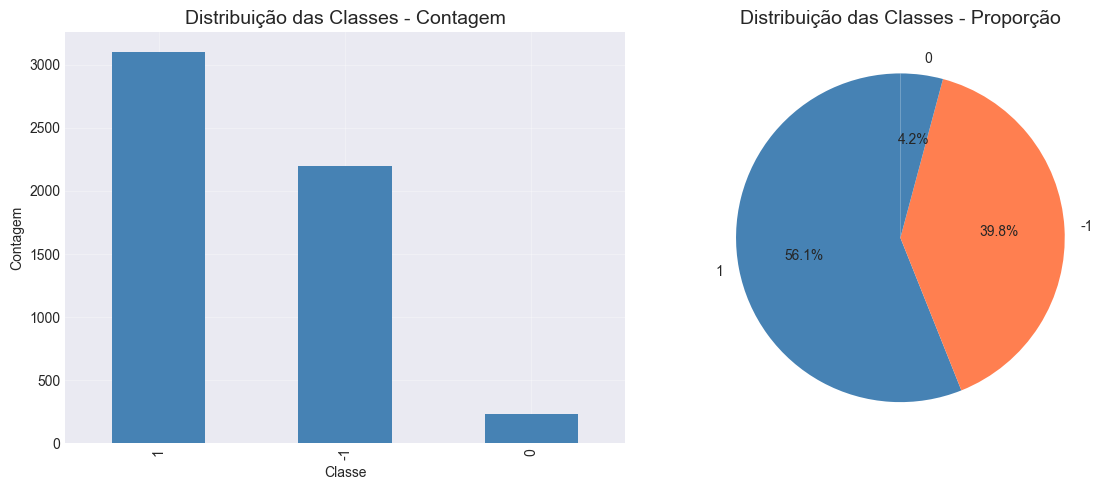

✓ Figura salva: ../results/figures/eda/figure_1.png


In [7]:
# Visualização da distribuição
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de barras
target_distribution['Count'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Distribuição das Classes - Contagem', fontsize=14)
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Contagem')
axes[0].grid(True, alpha=0.3)

# Gráfico de pizza
axes[1].pie(target_distribution['Count'], labels=target_distribution.index, 
           autopct='%1.1f%%', startangle=90, colors=['steelblue', 'coral'])
axes[1].set_title('Distribuição das Classes - Proporção', fontsize=14)

plt.tight_layout()
plt.savefig('../results/figures/eda/figure_1.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'✓ Figura salva: ../results/figures/eda/figure_1.png')

## 5. Análise de Valores Faltantes

In [8]:
# Valores faltantes
missing_values = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
})

missing_values = missing_values[missing_values['Missing_Count'] > 0].sort_values(
    'Missing_Percentage', ascending=False
)

if len(missing_values) > 0:
    print(f"Total de colunas com valores faltantes: {len(missing_values)}")
    print("\nTop 10 colunas com mais valores faltantes:")
    print(missing_values.head(10))
else:
    print("✓ Nenhum valor faltante encontrado no dataset!")

✓ Nenhum valor faltante encontrado no dataset!


## 6. Estatísticas Descritivas das Features

In [9]:
# Estatísticas descritivas
df[feature_cols].describe()

,ABC,ABCGG,nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,SpAD_A,SpMAD_A,LogEE_A,...,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2
count,5536.000000,5536.000000,5536.000000,5536.000000,5536.000000,5536.000000,5536.000000,5536.000000,5536.000000,5536.000000,...,5536.000000,5536.000000,5536.000000,5536.000000,5536.000000,5536.000000,5536.000000,5536.000000,5536.000000,5536.000000
mean,-0.005250,-0.006841,-0.027454,0.002899,-0.003598,-0.016812,-0.015381,-0.003598,-0.006840,-0.007976,...,-0.014970,-0.013456,-0.004159,0.009221,0.000494,-0.009452,-0.007451,-0.009390,-0.003014,-0.002552
std,1.017631,1.019341,0.967951,1.035796,1.019400,1.018107,1.022112,1.019400,1.019400,1.006973,...,1.018390,1.006240,1.023727,1.055642,1.058028,1.003402,1.011529,1.005649,1.028676,1.026120
min,-1.361875,-1.610180,-0.313685,-0.268813,-1.396640,-8.818209,-9.046588,-1.396640,-10.078430,-4.916346,...,-7.095252,-2.790236,-1.365297,-0.693512,-0.038245,-1.115638,-1.318872,-1.269696,-1.172567,-1.431613
25%,-0.538666,-0.519571,-0.313685,-0.268813,-0.548348,-0.356431,-0.314808,-0.548348,-0.363704,-0.536087,...,-0.337978,-0.635924,-0.502164,-0.285929,-0.038245,-0.606414,-0.569854,-0.605267,-0.439529,-0.504915
50%,-0.108075,-0.087082,-0.313685,-0.268813,-0.089840,0.114204,0.137195,-0.089840,0.140686,0.129077,...,0.171213,-0.082116,-0.133417,-0.161138,-0.038245,-0.182061,-0.120443,-0.150011,-0.156703,-0.113643
75%,0.349566,0.325708,-0.313685,-0.268813,0.356708,0.617946,0.613260,0.356708,0.598481,0.647983,...,0.610934,0.520549,0.247226,0.005156,-0.038245,0.412034,0.388890,0.403680,0.178070,0.272481
max,32.114987,32.058174,17.899849,25.637693,32.584328,3.266548,2.895291,32.584328,2.597684,5.639496,...,2.551411,23.729264,33.854649,26.334531,60.087950,26.976566,29.990098,27.694477,36.275862,34.894937


## 7. Análise de Correlação

In [10]:
# Correlação das features com o target
correlations = df[feature_cols].corrwith(df[target_col]).abs().sort_values(ascending=False)

print("Top 20 features mais correlacionadas com o target:")
print(correlations.head(20))

Top 20 features mais correlacionadas com o target:
SlogP_VSA8    0.305225
AATS3d        0.281848
nG12FRing     0.280755
AATS4d        0.272255
NaaaC         0.269280
naRing        0.266058
nG12FaRing    0.265499
CIC5          0.260666
nBondsA       0.259388
nAromBond     0.259388
n6aRing       0.255697
CIC4          0.255441
piPC9         0.254374
TpiPC10       0.254225
GATS1Z        0.254151
GATS1d        0.252586
GATS1m        0.252461
piPC10        0.250309
AATS2d        0.249306
piPC8         0.248011
dtype: float64


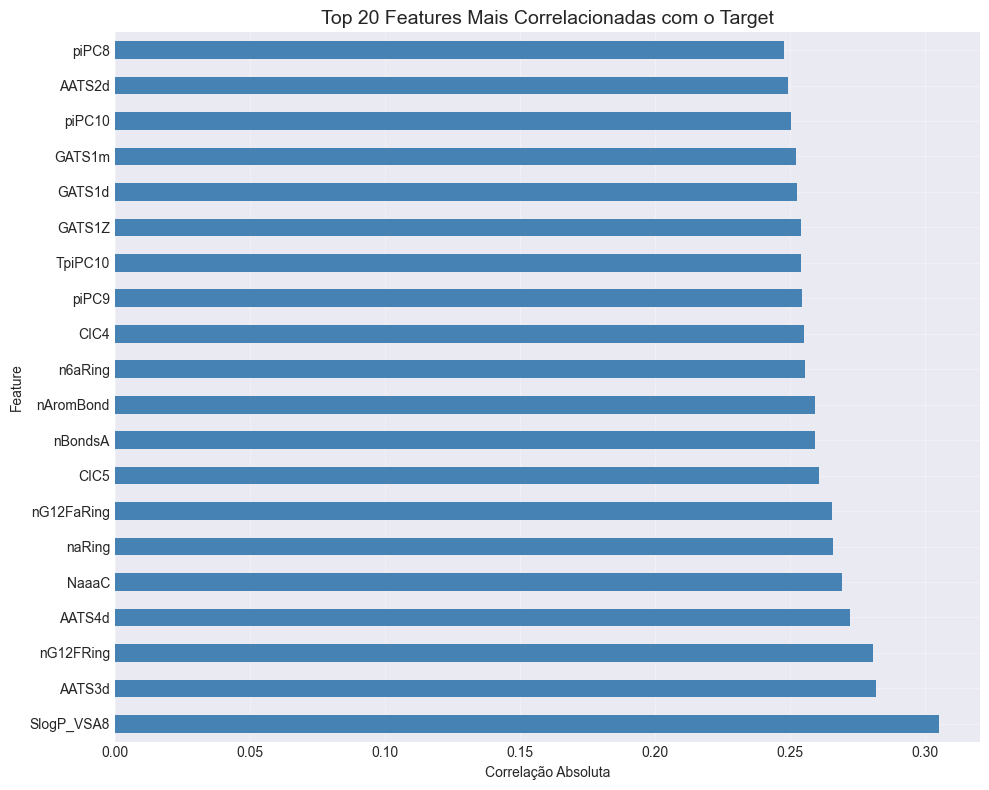

✓ Figura salva: ../results/figures/eda/figure_2.png


In [11]:
# Visualização das top correlações
fig, ax = plt.subplots(figsize=(10, 8))
top_corr = correlations.head(20)
top_corr.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 20 Features Mais Correlacionadas com o Target', fontsize=14)
ax.set_xlabel('Correlação Absoluta')
ax.set_ylabel('Feature')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/figures/eda/figure_2.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'✓ Figura salva: ../results/figures/eda/figure_2.png')

## 8. Distribuição de Features

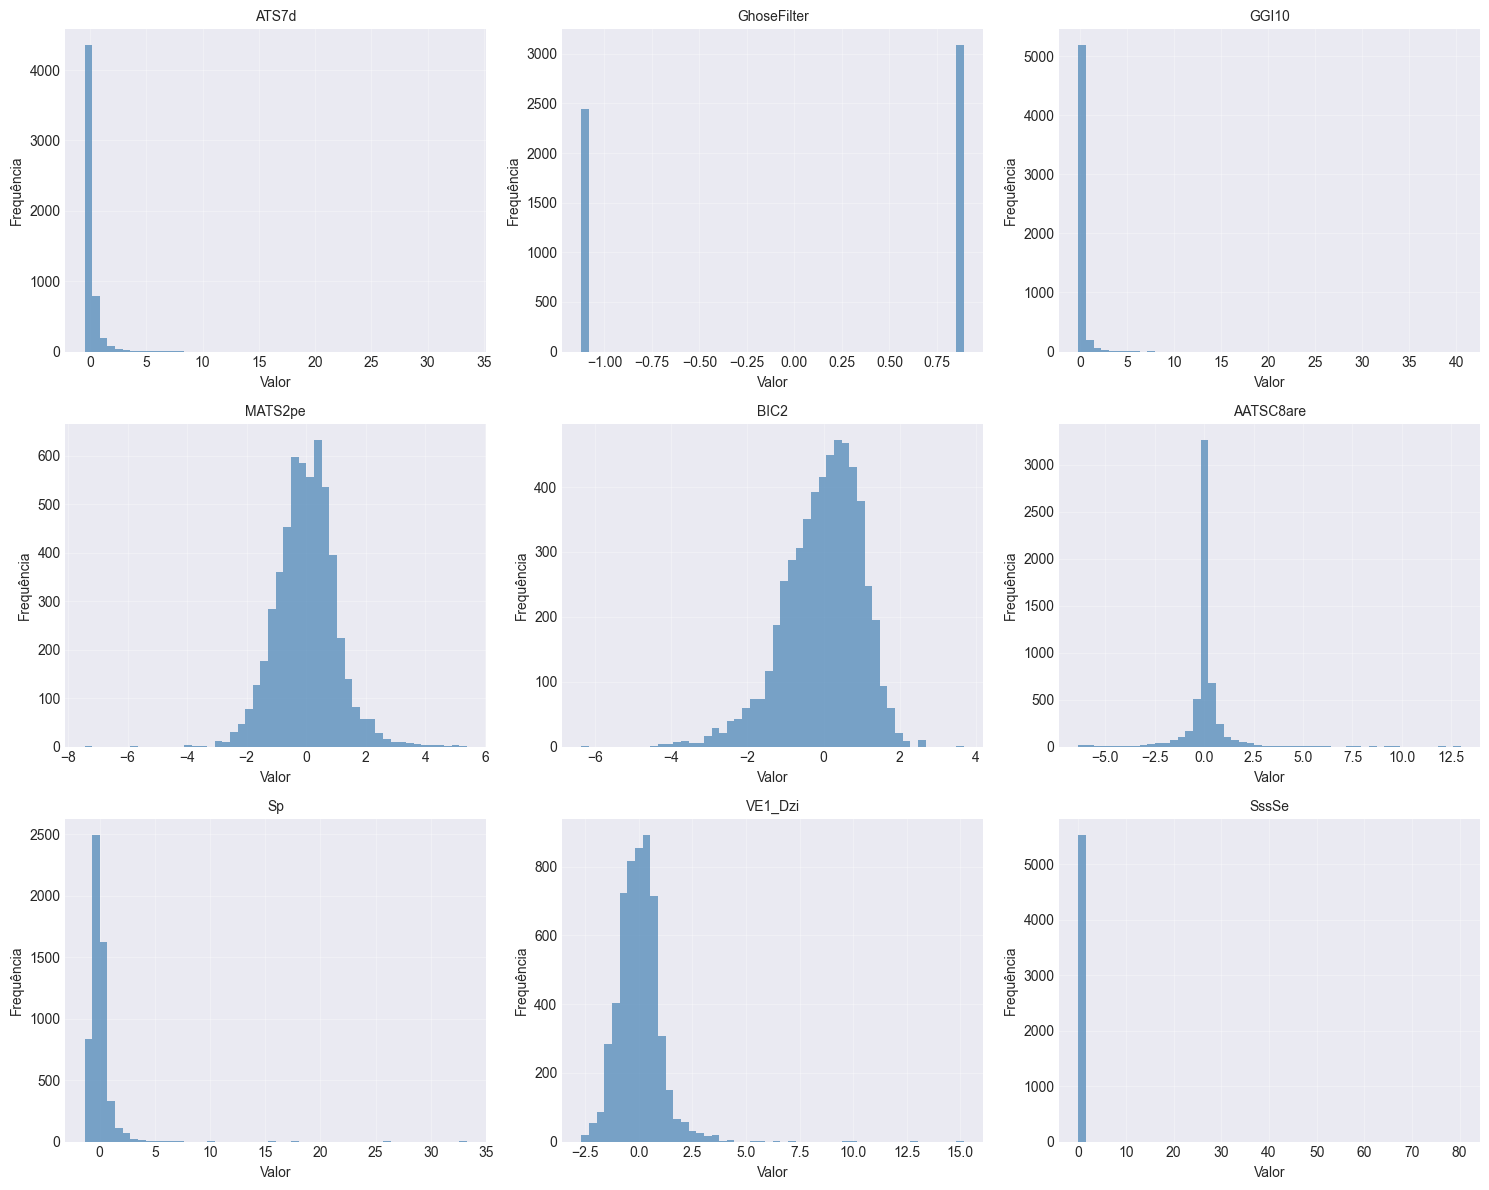

✓ Figura salva: ../results/figures/eda/figure_3.png


In [12]:
# Visualizar distribuição de algumas features aleatórias
selected_features = np.random.choice(feature_cols, size=9, replace=False)

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, feature in enumerate(selected_features):
    axes[idx].hist(df[feature].dropna(), bins=50, color='steelblue', alpha=0.7)
    axes[idx].set_title(f'{feature}', fontsize=10)
    axes[idx].set_xlabel('Valor')
    axes[idx].set_ylabel('Frequência')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/eda/figure_3.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'✓ Figura salva: ../results/figures/eda/figure_3.png')

## 9. Análise de Duplicatas

In [13]:
# Verificar duplicatas
n_duplicates = df.duplicated().sum()
print(f"Número de linhas duplicadas: {n_duplicates}")

if n_duplicates > 0:
    print("\nPrimeiras linhas duplicadas:")
    print(df[df.duplicated()].head())

Número de linhas duplicadas: 0


## 10. Conclusões da EDA

**Escreva aqui as principais conclusões da análise exploratória:**

1. Distribuição das classes (balanceamento)
2. Qualidade dos dados (missing values, duplicatas)
3. Características das features (escala, variância)
4. Features mais relevantes
5. Necessidades de pré-processamento identificadas

---

In [14]:
# Salvar resumo da EDA
import os
os.makedirs('../results/metrics/', exist_ok=True)

summary_path = '../results/metrics/eda_summary.txt'
with open(summary_path, 'w', encoding='utf-8') as f:
    f.write('='*60 + '\n')
    f.write('RESUMO DA ANÁLISE EXPLORATÓRIA DE DADOS\n')
    f.write('Dataset: Ames Mutagenicity\n')
    f.write('='*60 + '\n\n')
    
    f.write('1. DIMENSÕES DO DATASET\n')
    f.write(f'   - Total de amostras: {len(df)}\n')
    f.write(f'   - Total de features: {len(feature_cols)}\n')
    f.write(f'   - Shape: {df.shape}\n\n')
    
    f.write('2. VARIÁVEL ALVO (Overall)\n')
    dist = df[target_col].value_counts()
    dist_pct = df[target_col].value_counts(normalize=True) * 100
    for label in dist.index:
        f.write(f'   - {label}: {dist[label]} ({dist_pct[label]:.2f}%)\n')
    f.write('\n')
    
    f.write('3. VALORES FALTANTES\n')
    n_missing = df.isnull().sum().sum()
    f.write(f'   - Total: {n_missing}\n\n')
    
    f.write('4. DUPLICATAS\n')
    n_duplicates = df.duplicated().sum()
    f.write(f'   - Total: {n_duplicates}\n\n')
    
    f.write('5. ESTATÍSTICAS DAS FEATURES (primeiras 10)\n')
    desc = df[feature_cols[:10]].describe()
    f.write(desc.to_string())
    f.write('\n\n')
    
    f.write('='*60 + '\n')
    f.write('Resumo gerado automaticamente pelo notebook 01\n')
    f.write('='*60 + '\n')

print(f'✓ Resumo da EDA salvo em: {summary_path}')


✓ Resumo da EDA salvo em: ../results/metrics/eda_summary.txt
